# Retail Sales Analysis and Prediction Using E-Commerce Data

## Business Problem
E-commerce companies generate large amounts of transactional data but often struggle to extract meaningful insights from it.

## Objectives
- Analyze sales trends
- Predict order price
- Understand customer behavior

## Data Loading

In [1]:
import pandas as pd
import numpy as np

In [3]:
# Load datasets
customers = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_customers_dataset.csv")
orders = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_orders_dataset.csv")
order_items = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_order_items_dataset.csv")
products = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_products_dataset.csv")
payments = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_order_payments_dataset.csv")
reviews = pd.read_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\data\olist_order_reviews_dataset.csv")

In [4]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


## Data Merging

In [5]:
# Merge orders with customers
df = orders.merge(customers, on='customer_id', how='left')

# Merge with order items
df = df.merge(order_items, on='order_id', how='left')

# Merge with products
df = df.merge(products, on='product_id', how='left')

# Merge with payments
df = df.merge(payments, on='order_id', how='left')

# Merge with reviews
df = df.merge(reviews, on='order_id', how='left')

In [6]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58


In [7]:
df.shape

(119143, 36)

## Data Cleaning

In [8]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [9]:
df = df.drop_duplicates()
df.shape

(119143, 36)

In [10]:
# Fill missing review scores with median
df['review_score'] = df['review_score'].fillna(df['review_score'].median())

# Fill missing product category with 'Unknown'
df['product_category_name'] = df['product_category_name'].fillna('Unknown')

In [11]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name                 0
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


In [12]:
# Fill numerical columns with median
df['price'] = df['price'].fillna(df['price'].median())
df['freight_value'] = df['freight_value'].fillna(df['freight_value'].median())
df['payment_value'] = df['payment_value'].fillna(df['payment_value'].median())

df['product_weight_g'] = df['product_weight_g'].fillna(df['product_weight_g'].median())
df['product_length_cm'] = df['product_length_cm'].fillna(df['product_length_cm'].median())
df['product_height_cm'] = df['product_height_cm'].fillna(df['product_height_cm'].median())
df['product_width_cm'] = df['product_width_cm'].fillna(df['product_width_cm'].median())

In [13]:
# Fill text columns
df['review_comment_message'] = df['review_comment_message'].fillna('No Comment')

In [14]:
df.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                                 0
freight_value                         0
product_category_name                 0
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                      0
product_length_cm                     0
product_height_cm                     0


## Exploratory Data Analysis (EDA)

In [15]:
# Convert to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [16]:
# Create new time features
df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month

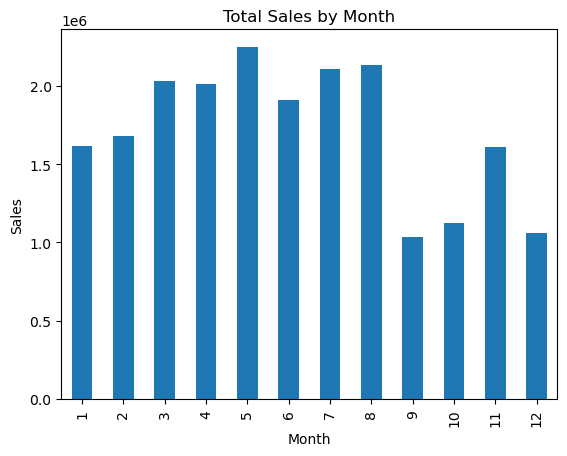

In [17]:
import matplotlib.pyplot as plt

# Sales per month
monthly_sales = df.groupby('month')['payment_value'].sum()

monthly_sales.plot(kind='bar')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

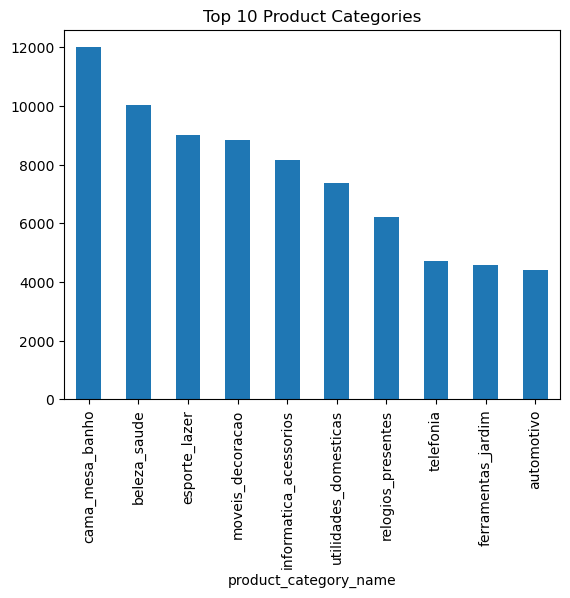

In [18]:
top_products = df['product_category_name'].value_counts().head(10)

top_products.plot(kind='bar')
plt.title('Top 10 Product Categories')
plt.show()

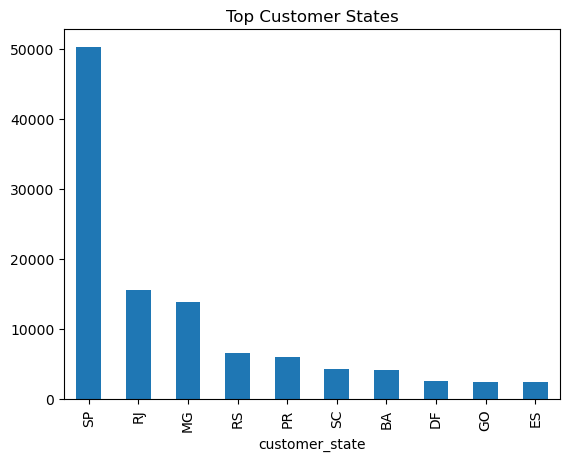

In [19]:
df['customer_state'].value_counts().head(10).plot(kind='bar')
plt.title('Top Customer States')
plt.show()

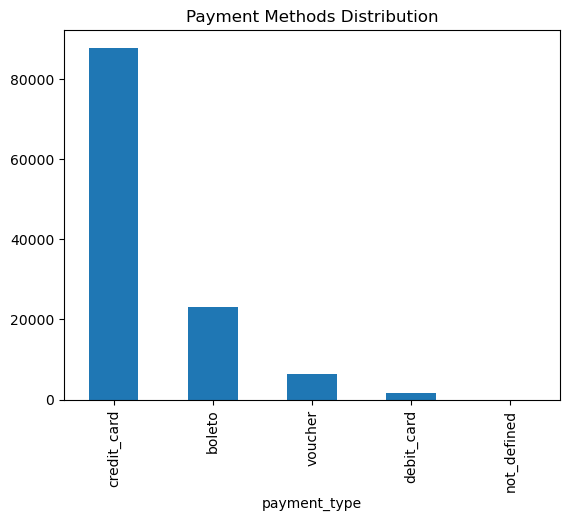

In [20]:
df['payment_type'].value_counts().plot(kind='bar')
plt.title('Payment Methods Distribution')
plt.show()

## Feature Engineering

In [21]:
# Aggregate order-level data
model_df = df.groupby('order_id').agg({
    'payment_value': 'sum',
    'price': 'mean',
    'freight_value': 'mean',
    'product_weight_g': 'mean',
    'product_length_cm': 'mean',
    'product_height_cm': 'mean',
    'product_width_cm': 'mean',
    'review_score': 'mean'
}).reset_index()

In [22]:
X = model_df.drop(['order_id', 'payment_value'], axis=1)
y = model_df['payment_value']

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 108.14561941803034
R2 Score: 0.029081281187909425


In [27]:
!pip install shap

In [28]:
import shap

In [29]:
X_sample = X_test.sample(100, random_state=42)

In [30]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

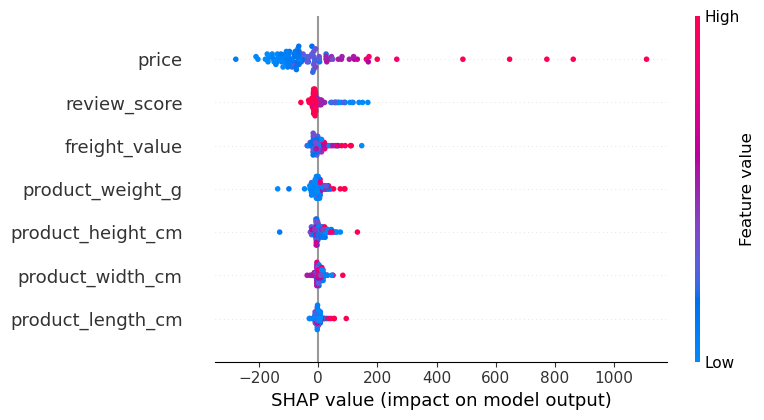

In [31]:
shap.summary_plot(shap_values, X_sample)

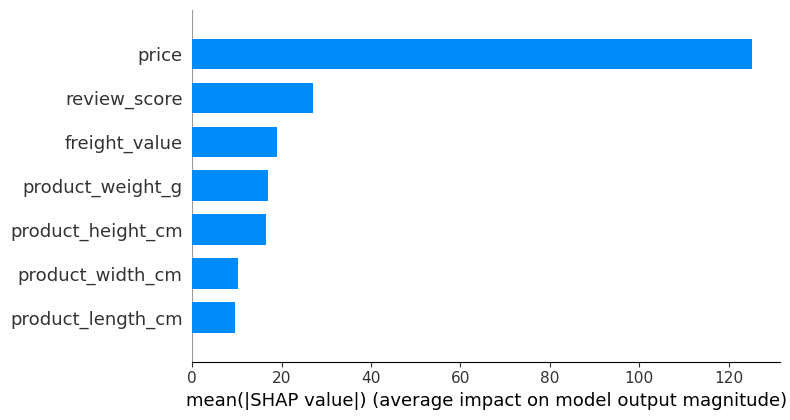

In [32]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

## Bias Analysis

In [38]:
# Bias Analysis: Check differences across customer groups
# Compare average payment by customer state
df.groupby('customer_state')['payment_value'].mean().sort_values(ascending=False).head(10)

customer_state
PB    282.081879
AC    262.998526
AP    257.651190
AL    242.018254
RR    239.657885
PI    238.123073
RO    236.933151
MA    234.069206
PA    233.142338
MT    227.740512
Name: payment_value, dtype: float64

In [39]:
# Compare by payment type
df.groupby('payment_type')['payment_value'].mean()

payment_type
boleto         177.271270
credit_card    179.723963
debit_card     150.864531
not_defined      0.000000
voucher         67.427353
Name: payment_value, dtype: float64

In [40]:
import pickle

# Save model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [41]:
def predict_order_value(input_data):
    return model.predict(input_data)

In [43]:
df.to_csv(r"C:\Users\student\Downloads\Business_Analytics_Project\Business_Analytics_Project\final_dataset.csv", index=False)

In [44]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Business_Analytics_Dashboard.pbix',
 'Business_Analytics_Project.ipynb',
 'data',
 'final_dataset.csv',
 'model.pkl',
 'README.txt.txt',
 'Retail Sales Analysis and Prediction Using E-Commerce Data.pdf']